In [2]:
import numpy as np
import matplotlib.pyplot as plt

# step1 : load data
data = np.load("mnist.npz")
Xtr_full, ytr_full = data["x_train"], data["y_train"]
Xte_full, yte_full = data["x_test"],  data["y_test"]
print("Train raw:", Xtr_full.shape, "Test raw:", Xte_full.shape)


Train raw: (60000, 28, 28) Test raw: (10000, 28, 28)


In [3]:
# step2 : filter 4 & 9
tr_mask = (ytr_full == 4) | (ytr_full == 9)
te_mask = (yte_full == 4) | (yte_full == 9)
Xtr_f, ytr_f = Xtr_full[tr_mask], ytr_full[tr_mask]
Xte_f, yte_f = Xte_full[te_mask], yte_full[te_mask]
print("Filtered train:", Xtr_f.shape, "Filtered test:", Xte_f.shape)


Filtered train: (11791, 28, 28) Filtered test: (1991, 28, 28)


In [4]:


# step3 : relabel -1/+1
ytr_f = np.where(ytr_f == 4, -1, 1)
yte_f = np.where(yte_f == 4, -1, 1)
print("Train labels unique:", np.unique(ytr_f, return_counts=True))
print("Test  labels unique:", np.unique(yte_f, return_counts=True))



Train labels unique: (array([-1,  1]), array([5842, 5949]))
Test  labels unique: (array([-1,  1]), array([ 982, 1009]))


In [5]:

# step4 : flatten & normalize
Xtr_f = Xtr_f.reshape(len(Xtr_f), -1) / 255.0
Xte_f = Xte_f.reshape(len(Xte_f), -1) / 255.0
print("Flattened train:", Xtr_f.shape, "Flattened test:", Xte_f.shape)


Flattened train: (11791, 784) Flattened test: (1991, 784)


In [6]:

# step5 : split val (1000 per class)
def split_val(X, y, n=1000):
    idx_n1 = np.where(y == -1)[0]
    idx_p1 = np.where(y ==  1)[0]
    val_idx = np.concatenate([idx_n1[:n], idx_p1[:n]])
    tr_idx  = np.concatenate([idx_n1[n:], idx_p1[n:]])
    return X[tr_idx], y[tr_idx], X[val_idx], y[val_idx]

Xtr, ytr, Xval, yval = split_val(Xtr_f, ytr_f)
print("Train:", Xtr.shape, ytr.shape,
      "Val:", Xval.shape, yval.shape)


Train: (9791, 784) (9791,) Val: (2000, 784) (2000,)


In [7]:

# step6 : PCA on train only
def fit_pca(X, k=5):
    mu   = X.mean(axis=0)
    Xc   = X - mu
    C    = Xc.T @ Xc / (len(X) - 1)
    vals, vecs = np.linalg.eigh(C)
    idx  = np.argsort(vals)[::-1]
    W    = vecs[:, idx[:k]]
    return mu, W

def apply_pca(X, mu, W):
    return (X - mu) @ W

mu_pca, W_pca = fit_pca(Xtr, k=5)
Xtr_p  = apply_pca(Xtr,  mu_pca, W_pca)
Xval_p = apply_pca(Xval, mu_pca, W_pca)
Xte_p  = apply_pca(Xte_f, mu_pca, W_pca)
print("PCA train:", Xtr_p.shape,
      "PCA val:",  Xval_p.shape,
      "PCA test:", Xte_p.shape)
print("W_pca shape:", W_pca.shape, "mu shape:", mu_pca.shape)


PCA train: (9791, 5) PCA val: (2000, 5) PCA test: (1991, 5)
W_pca shape: (784, 5) mu shape: (784,)


In [8]:

# step7 : stump definition
def best_stump(X, y, w, rng, n_thresh=1000):
    n, d  = X.shape
    best  = dict(err=np.inf, feat=0, thr=0.0, pol=1)
    for j in range(d):
        vals = np.unique(X[:, j])
        if len(vals) < 2:
            continue
        cands = (vals[:-1] + vals[1:]) / 2.0
        if len(cands) > n_thresh:
            cands = rng.choice(cands, n_thresh, replace=False)
        for thr in cands:
            for pol in (1, -1):
                pred = np.where(X[:, j] <= thr, pol, -pol)
                err  = np.sum(w[pred != y])
                if err < best["err"]:
                    best = dict(err=err, feat=j, thr=thr, pol=pol)
    return best

def stump_predict(X, stump):
    j, thr, pol = stump["feat"], stump["thr"], stump["pol"]
    return np.where(X[:, j] <= thr, pol, -pol)


In [9]:

# step8 : adaboost loop
rng      = np.random.default_rng(42)
n        = len(Xtr_p)
w        = np.ones(n) / n
stumps   = []
alphas   = []
val_accs = []
T        = 300

for t in range(T):
    # step8a : grow stump
    s     = best_stump(Xtr_p, ytr, w, rng)
    pred  = stump_predict(Xtr_p, s)
    err   = s["err"]
    err   = np.clip(err, 1e-10, 1 - 1e-10)

    # step8b : alpha
    alpha = 0.5 * np.log((1 - err) / err)

    # step8c : update weights
    w = w * np.exp(-alpha * ytr * pred)
    w = w / w.sum()

    stumps.append(s)
    alphas.append(alpha)

    # step8d : val accuracy
    scores = sum(a * stump_predict(Xval_p, st)
                 for a, st in zip(alphas, stumps))
    val_acc = np.mean(np.sign(scores) == yval)
    val_accs.append(val_acc)

    if (t + 1) % 50 == 0:
        print(f"  iter {t+1:3d} | err={err:.4f} | alpha={alpha:.4f} "
              f"| val_acc={val_acc:.4f} | w_sum={w.sum():.4f}")


  iter  50 | err=0.4800 | alpha=0.0400 | val_acc=0.8105 | w_sum=1.0000
  iter 100 | err=0.4915 | alpha=0.0170 | val_acc=0.8080 | w_sum=1.0000
  iter 150 | err=0.4939 | alpha=0.0122 | val_acc=0.8095 | w_sum=1.0000
  iter 200 | err=0.4935 | alpha=0.0129 | val_acc=0.8090 | w_sum=1.0000
  iter 250 | err=0.4942 | alpha=0.0116 | val_acc=0.8100 | w_sum=1.0000
  iter 300 | err=0.4950 | alpha=0.0101 | val_acc=0.8095 | w_sum=1.0000


In [10]:

# step9 : best iteration
best_t   = int(np.argmax(val_accs))
print(f"\nBest iteration: {best_t+1}  Val acc: {val_accs[best_t]:.4f}")



Best iteration: 96  Val acc: 0.8125


In [11]:

# step10 : test accuracy
scores_te = sum(alphas[t] * stump_predict(Xte_p, stumps[t])
                for t in range(best_t + 1))
test_acc  = np.mean(np.sign(scores_te) == yte_f)
print(f"Test accuracy at iter {best_t+1}: {test_acc:.4f}")


Test accuracy at iter 96: 0.7996


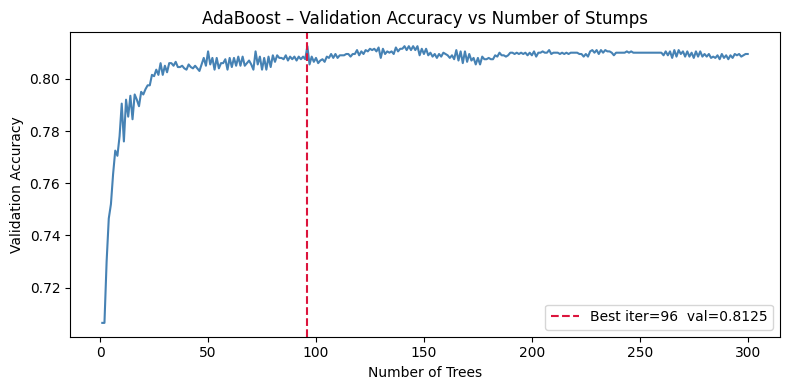

Plot saved: q1_val_accuracy.png
alphas[:5]: [np.float64(0.3719942828114707), np.float64(0.27995717023511224), np.float64(0.28683622255832075), np.float64(0.2053019939919379), np.float64(0.20661805546092174)]
Weights after last update (min/max/mean): 5.236288981787529e-06 0.001733937453126072 0.0001021346134204882


In [12]:

# step11 : plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, T+1), val_accs, linewidth=1.5, color="steelblue")
plt.axvline(best_t + 1, color="crimson", linestyle="--",
            label=f"Best iter={best_t+1}  val={val_accs[best_t]:.4f}")
plt.xlabel("Number of Trees")
plt.ylabel("Validation Accuracy")
plt.title("AdaBoost – Validation Accuracy vs Number of Stumps")
plt.legend()
plt.tight_layout()
plt.savefig("q1_val_accuracy.png", dpi=150)
plt.show()
print("Plot saved: q1_val_accuracy.png")
print("alphas[:5]:", alphas[:5])
print("Weights after last update (min/max/mean):",
      w.min(), w.max(), w.mean())